# Dead ReLU Recovery via Mixed-Rank Weight Decomposition

This notebook demonstrates how **splitting weights mid-training** — adding the decomposition $W_{\text{eff}} = W + \sum_i B_i C_i$ — can revive dead neurons through the coupling matrix $P = I + \sum_i B_i B_i^\top$.

**Protocol**:
1. Start with an MLP where ~50% of neurons are killed (bias set to $-5$)
2. Train for 2 warmup epochs (shared)
3. Fork into two branches from the **same** checkpoint:
   - **Baseline**: continue training as-is for 40 epochs
   - **Baseline + Split**: add low-rank factors, merge+resplit every 10 epochs (at post-epochs 10, 20, 30)
4. The split model revives dead neurons; the baseline cannot

In [1]:
import sys
sys.path.insert(0, "../src")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy

from WeightDecomp import DecomposedLinear, DecomposedMLP
from WeightDecomp.train_mnist import train_epoch, evaluate, reset_factor_optimizer_state

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_set = torchvision.datasets.MNIST(root="../data", train=True, transform=transform, download=False)
test_set = torchvision.datasets.MNIST(root="../data", train=False, transform=transform, download=False)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256)

## Dead Neuron Detection & Killing

A neuron $j$ is **dead** if its pre-activation $z_j(\mathbf{x}) < 0$ for all inputs $\mathbf{x}$ in the data (Definition 1 in the paper). We detect this by tracking the maximum pre-activation per neuron across many batches — if `max < 0`, the neuron never fires.

To create a controlled experiment, `kill_neurons` sets selected biases to a large negative value so those neurons are guaranteed dead at the start of training.

In [3]:
@torch.no_grad()
def count_dead_neurons(model, loader, device, max_batches=50):
    """Count dead neurons per hidden layer.
    
    A neuron is dead if its pre-activation is < 0 for every sample checked.
    We track the max pre-activation per neuron; if max < 0, the neuron is dead.
    
    Returns:
        dict mapping layer index -> (num_dead, total_neurons)
    """
    model.eval()
    layers = model.decomposed_layers()
    hidden_layers = layers[:-1]  # only hidden layers (not output)
    
    max_preact = [torch.full((l.out_features,), -float("inf"), device=device) for l in hidden_layers]
    
    for batch_idx, (images, _) in enumerate(loader):
        if batch_idx >= max_batches:
            break
        x = images.to(device).view(images.size(0), -1)
        for i, layer in enumerate(hidden_layers):
            preact = layer(x)
            batch_max = preact.max(dim=0).values
            max_preact[i] = torch.maximum(max_preact[i], batch_max)
            x = F.relu(preact)
    
    result = {}
    for i, mp in enumerate(max_preact):
        num_dead = (mp < 0).sum().item()
        total = mp.numel()
        result[i] = (num_dead, total)
    return result


def kill_neurons(model, frac=0.5, bias_val=-5.0, seed=123):
    """Kill a fraction of neurons in each hidden layer by setting their bias
    to a large negative value, ensuring z_j(x) < 0 for all inputs.
    
    Args:
        model: DecomposedMLP
        frac: fraction of neurons to kill per hidden layer
        bias_val: negative bias value (more negative = more certainly dead)
        seed: for reproducible neuron selection
    """
    rng = torch.Generator().manual_seed(seed)
    layers = model.decomposed_layers()
    for layer in layers[:-1]:  # hidden layers only
        n = layer.out_features
        n_kill = int(n * frac)
        perm = torch.randperm(n, generator=rng)
        kill_idx = perm[:n_kill]
        with torch.no_grad():
            layer.bias.data[kill_idx] = bias_val
        print(f"  Killed {n_kill}/{n} neurons (bias <- {bias_val})")

## Create Base Model, Kill Neurons, and Shared Warmup

We create one model, kill ~50% of neurons, then train it for a warmup phase. At the split point, we fork into separate experiments.

In [4]:
torch.manual_seed(42)
layer_sizes = [784, 64, 32, 32, 32, 10]

# Create base model (no factors) and kill neurons
base_model = DecomposedMLP(layer_sizes).to(device)
print("Killing neurons in base model:")
kill_neurons(base_model, frac=0.5, bias_val=-5.0)

# Verify they're dead
dead_init = count_dead_neurons(base_model, train_loader, device)
for i, (d, t) in dead_init.items():
    print(f"  Layer {i}: {d}/{t} dead neurons ({100*d/t:.0f}%)")

# --- Shared warmup phase ---
WARMUP_EPOCHS = 2

optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

warmup_dead = [count_dead_neurons(base_model, train_loader, device)]
warmup_losses = []
warmup_accs = []

print(f"\n--- Shared warmup ({WARMUP_EPOCHS} epochs) ---")
for epoch in range(1, WARMUP_EPOCHS + 1):
    train_loss, train_acc = train_epoch(base_model, train_loader, optimizer, criterion, device)
    test_acc = evaluate(base_model, test_loader, device)
    warmup_losses.append(train_loss)
    warmup_accs.append(test_acc)
    warmup_dead.append(count_dead_neurons(base_model, train_loader, device))
    
    dead_str = ", ".join(f"L{i}: {d}/{t}" for i, (d, t) in warmup_dead[-1].items())
    print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | Test: {100*test_acc:.2f}% | Dead: [{dead_str}]")

print(f"\nAfter warmup, dead neurons are stuck. Now we fork.")

Killing neurons in base model:
  Killed 32/64 neurons (bias <- -5.0)
  Killed 16/32 neurons (bias <- -5.0)
  Killed 16/32 neurons (bias <- -5.0)
  Killed 16/32 neurons (bias <- -5.0)
  Layer 0: 32/64 dead neurons (50%)
  Layer 1: 16/32 dead neurons (50%)
  Layer 2: 21/32 dead neurons (66%)
  Layer 3: 22/32 dead neurons (69%)

--- Shared warmup (2 epochs) ---
Epoch   1 | Loss: 0.8256 | Test: 89.46% | Dead: [L0: 36/64, L1: 12/32, L2: 14/32, L3: 11/32]
Epoch   2 | Loss: 0.2975 | Test: 92.12% | Dead: [L0: 36/64, L1: 11/32, L2: 13/32, L3: 9/32]

After warmup, dead neurons are stuck. Now we fork.


## Fork and Continue Training

Each experiment deep-copies the warmed-up model. The split experiment adds factors ($C=0$, so the function is identical at the fork point), then continues training.

In [5]:
def continue_training(base_model, ranks=None, epochs=40, lr=1e-3, merge_resplit_every=None):
    """Fork from a warmed-up model and continue training.
    
    If ranks is provided, split the weights first (adding factors with C=0).
    If merge_resplit_every is set, merge+resplit at those intervals.
    """
    model = copy.deepcopy(base_model)
    
    if ranks:
        model.split_all(ranks)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    dead_counts = [count_dead_neurons(model, train_loader, device)]
    train_losses = []
    test_accs = []
    
    for epoch in range(1, epochs + 1):
        # Merge + resplit at specified intervals
        if (merge_resplit_every and ranks
                and epoch > 1 and (epoch - 1) % merge_resplit_every == 0):
            model.merge_all(rerandomize_B=True)
            reset_factor_optimizer_state(optimizer, model)
            print(f"  [Merge + resplit at post-warmup epoch {epoch}]")
        
        train_loss, _ = train_epoch(model, train_loader, optimizer, criterion, device)
        test_acc = evaluate(model, test_loader, device)
        
        train_losses.append(train_loss)
        test_accs.append(test_acc)
        dead_counts.append(count_dead_neurons(model, train_loader, device))
        
        if epoch % 5 == 0 or epoch == 1:
            dead_str = ", ".join(
                f"L{i}: {d}/{t}" for i, (d, t) in dead_counts[-1].items()
            )
            print(
                f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | "
                f"Test: {100*test_acc:.2f}% | Dead: [{dead_str}]"
            )
    
    return {
        "dead_counts": dead_counts,
        "train_losses": train_losses,
        "test_accs": test_accs,
    }

## Experiment 1: Baseline — continue without split

No intervention. Dead neurons remain trapped (gradient row $G_{j,\cdot} = 0$).

In [6]:
POST_EPOCHS = 40

print("=== Baseline (no split) ===")
baseline = continue_training(base_model, ranks=None, epochs=POST_EPOCHS)

=== Baseline (no split) ===
Epoch   1 | Loss: 0.2414 | Test: 93.15% | Dead: [L0: 36/64, L1: 11/32, L2: 12/32, L3: 10/32]
Epoch   5 | Loss: 0.1389 | Test: 95.37% | Dead: [L0: 36/64, L1: 11/32, L2: 13/32, L3: 9/32]
Epoch  10 | Loss: 0.0982 | Test: 96.30% | Dead: [L0: 36/64, L1: 9/32, L2: 13/32, L3: 9/32]
Epoch  15 | Loss: 0.0772 | Test: 96.52% | Dead: [L0: 36/64, L1: 9/32, L2: 13/32, L3: 9/32]
Epoch  20 | Loss: 0.0619 | Test: 96.61% | Dead: [L0: 36/64, L1: 9/32, L2: 12/32, L3: 8/32]
Epoch  25 | Loss: 0.0549 | Test: 96.56% | Dead: [L0: 36/64, L1: 9/32, L2: 12/32, L3: 8/32]
Epoch  30 | Loss: 0.0464 | Test: 96.41% | Dead: [L0: 36/64, L1: 8/32, L2: 12/32, L3: 7/32]
Epoch  35 | Loss: 0.0412 | Test: 96.20% | Dead: [L0: 36/64, L1: 8/32, L2: 10/32, L3: 8/32]
Epoch  40 | Loss: 0.0332 | Test: 96.50% | Dead: [L0: 36/64, L1: 8/32, L2: 11/32, L3: 7/32]


## Experiment 2: Split at the fork, merge+resplit every 10 epochs

Add factors at the fork, then merge+resplit at post-epochs 10, 20, 30 to refresh coupling directions.

In [9]:
ranks = [4, 8]
print(f"=== Baseline + Split (ranks={ranks}, merge+resplit every 10 epochs) ===")
split_result = continue_training(base_model, ranks=ranks, epochs=POST_EPOCHS, merge_resplit_every=10)

=== Baseline + Split (ranks=[4, 8], merge+resplit every 10 epochs) ===
Epoch   1 | Loss: 0.2419 | Test: 93.50% | Dead: [L0: 36/64, L1: 10/32, L2: 13/32, L3: 9/32]
Epoch   5 | Loss: 0.1164 | Test: 96.14% | Dead: [L0: 24/64, L1: 7/32, L2: 10/32, L3: 8/32]
Epoch  10 | Loss: 0.0733 | Test: 96.64% | Dead: [L0: 15/64, L1: 5/32, L2: 6/32, L3: 6/32]
  [Merge + resplit at post-warmup epoch 11]
Epoch  15 | Loss: 0.0466 | Test: 96.57% | Dead: [L0: 15/64, L1: 4/32, L2: 5/32, L3: 6/32]
Epoch  20 | Loss: 0.0331 | Test: 97.00% | Dead: [L0: 13/64, L1: 5/32, L2: 6/32, L3: 4/32]
  [Merge + resplit at post-warmup epoch 21]
Epoch  25 | Loss: 0.0273 | Test: 96.49% | Dead: [L0: 13/64, L1: 5/32, L2: 6/32, L3: 5/32]
Epoch  30 | Loss: 0.0234 | Test: 96.84% | Dead: [L0: 13/64, L1: 3/32, L2: 6/32, L3: 5/32]
  [Merge + resplit at post-warmup epoch 31]
Epoch  35 | Loss: 0.0166 | Test: 96.90% | Dead: [L0: 12/64, L1: 3/32, L2: 6/32, L3: 3/32]
Epoch  40 | Loss: 0.0144 | Test: 97.18% | Dead: [L0: 12/64, L1: 3/32, L2: 

## Results

Split epoch: 2
Merge epoch: 12
Merge epoch: 22
Merge epoch: 32


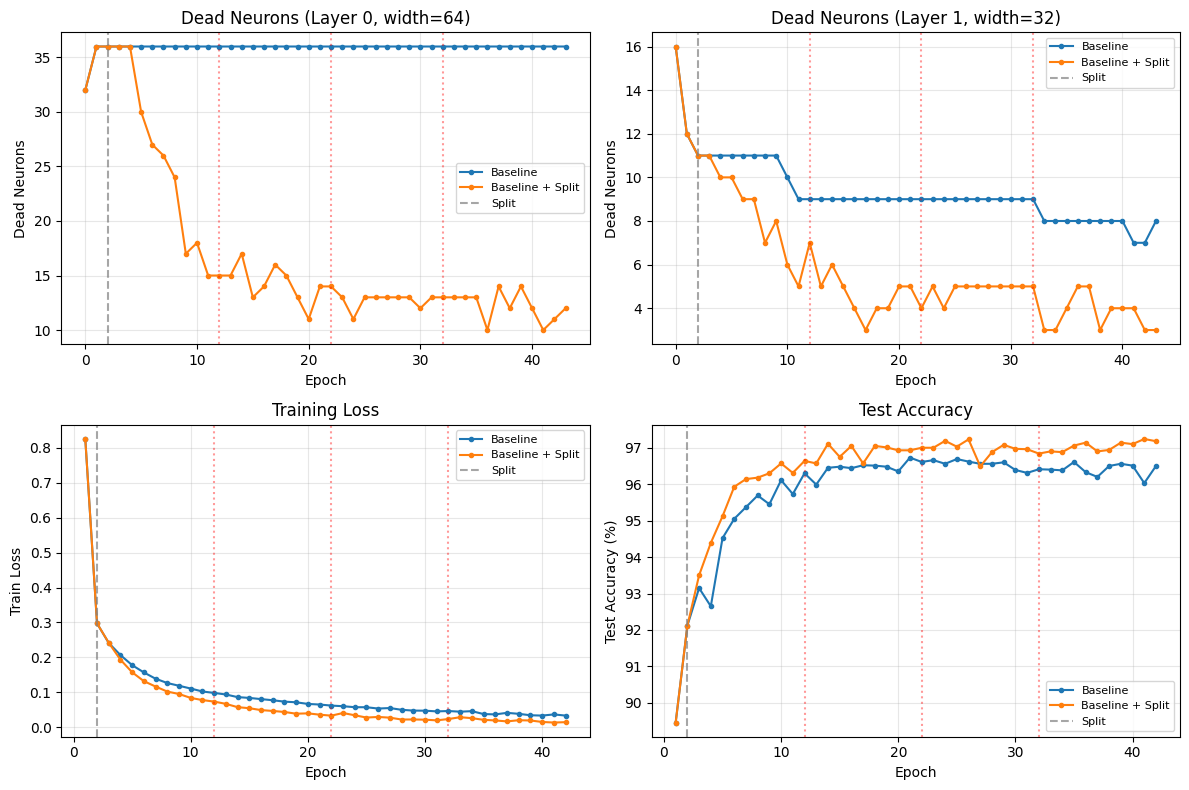

In [10]:
def full_dead_timeseries(warmup_dead, post_result, layer_idx=0):
    warmup = [dc[layer_idx][0] for dc in warmup_dead]
    post = [dc[layer_idx][0] for dc in post_result["dead_counts"]]
    return warmup + post

def full_acc_timeseries(warmup_accs, post_result):
    return warmup_accs + post_result["test_accs"]

def full_loss_timeseries(warmup_losses, post_result):
    return warmup_losses + post_result["train_losses"]

experiments = {
    "Baseline": baseline,
    "Baseline + Split": split_result,
}

split_epoch = WARMUP_EPOCHS
merge_epochs = [WARMUP_EPOCHS + e for e in [10, 20, 30]]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Dead neurons layer 0
ax = axes[0, 0]
for name, result in experiments.items():
    ts = full_dead_timeseries(warmup_dead, result, 0)
    ax.plot(range(len(ts)), ts, label=name, marker="o", markersize=3)
print(f"Split epoch: {split_epoch}")
ax.axvline(x=split_epoch, color="gray", linestyle="--", alpha=0.7, label="Split")
for me in merge_epochs:
    print(f"Merge epoch: {me}")
    ax.axvline(x=me, color="red", linestyle=":", alpha=0.4,
        label="Merge+resplit" if i == 0 else None)
ax.set_xlabel("Epoch")
ax.set_ylabel("Dead Neurons")
ax.set_title("Dead Neurons (Layer 0, width=64)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Dead neurons layer 1
ax = axes[0, 1]
for name, result in experiments.items():
    ts = full_dead_timeseries(warmup_dead, result, 1)
    ax.plot(range(len(ts)), ts, label=name, marker="o", markersize=3)
ax.axvline(x=split_epoch, color="gray", linestyle="--", alpha=0.7, label="Split")
for me in merge_epochs:
    ax.axvline(x=me, color="red", linestyle=":", alpha=0.4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Dead Neurons")
ax.set_title("Dead Neurons (Layer 1, width=32)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Train loss
ax = axes[1, 0]
for name, result in experiments.items():
    ts = full_loss_timeseries(warmup_losses, result)
    ax.plot(range(1, len(ts) + 1), ts, label=name, marker="o", markersize=3)
ax.axvline(x=split_epoch, color="gray", linestyle="--", alpha=0.7, label="Split")
for me in merge_epochs:
    ax.axvline(x=me, color="red", linestyle=":", alpha=0.4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train Loss")
ax.set_title("Training Loss")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Test accuracy
ax = axes[1, 1]
for name, result in experiments.items():
    ts = full_acc_timeseries(warmup_accs, result)
    ax.plot(range(1, len(ts) + 1), [100 * a for a in ts], label=name, marker="o", markersize=3)
ax.axvline(x=split_epoch, color="gray", linestyle="--", alpha=0.7, label="Split")
for me in merge_epochs:
    ax.axvline(x=me, color="red", linestyle=":", alpha=0.4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("dead_relu_recovery.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

Both models are **functionally identical** at the split point (epoch 10). The only difference is the optimization geometry:

- **Baseline**: continues with standard parameterization ($P = I$, diagonal coupling). Dead neurons stay dead — their gradient rows are zero, so no update is possible.
- **Baseline + Split**: adding factors creates off-diagonal coupling $P = I + \sum_i B_i B_i^\top$. At epoch 30, merge absorbs $BC$ into $W$ and re-randomizes $B$ to refresh coupling directions for continued revival.

This is the **dynamic gauge transformation** from Section 5: same function, different parameterization, different optimization trajectory.